# ECG_MIT_RSIN_16265

Este notebook procesa una señal de electrocardiograma (ECG) para identificar las ondas P, Q, R, S y T. Incluye el filtrado de la señal para eliminar la desviación de la línea base y el ruido de alta frecuencia, la detección algorítmica de puntos fiduciales y el cálculo de intervalos clínicos (RR, PR, QRS, QT) para determinar la frecuencia cardíaca y posibles patologías.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import find_peaks

# --- Carga de Datos ---
filename = '/content/sample_data/ECG_MIT_RSIN_16265.txt'
# Asumiendo un formato estándar: omitir 2 filas de encabezado, tiempo en col 0, señal en col 1
# Como solo necesitamos la señal y la Fs es conocida, usamos usecols=1
data = np.loadtxt(filename, dtype=float, skiprows=2, usecols=1)
ecg_signal = data

Fs = 125  # Frecuencia de muestreo estándar para este conjunto de datos
Ts = 1 / Fs
N = len(ecg_signal)
t = np.arange(0, N * Ts, Ts)
if len(t) > N:
    t = t[:N]
elif len(t) < N:
    t = np.linspace(0, (N-1)*Ts, N)

print(f"Datos cargados con éxito. Muestras totales: {N}")

Datos cargados con éxito. Muestras totales: 1280


In [2]:
# --- Filtrado de Señal ---
FCI = 0.05
FCS = 15
Nyquist = 0.5 * Fs
b, a = signal.butter(2, [FCI / Nyquist, FCS / Nyquist], btype='bandpass')
ecg_filtered = signal.filtfilt(b, a, ecg_signal)

print("Filtrado aplicado.")

Filtrado aplicado.


In [3]:
# --- Detección de Puntos Fiduciales PQRST ---
r_threshold = 0.6 * np.max(ecg_filtered)
r_distance = int(0.3 * Fs)

peaks, _ = find_peaks(ecg_filtered, height=r_threshold, distance=r_distance)

p_waves = []
q_waves = []
s_waves = []
t_waves = []

win_q = int(0.06 * Fs)
win_s = int(0.06 * Fs)
win_p = int(0.20 * Fs)
win_t = int(0.40 * Fs)

for r in peaks:
    if r - win_q - win_p < 0 or r + win_s + win_t >= len(ecg_filtered):
        continue

    q_window = ecg_filtered[r - win_q : r]
    q = (r - win_q) + np.argmin(q_window)
    q_waves.append(q)

    s_window = ecg_filtered[r : r + win_s]
    s = r + np.argmin(s_window)
    s_waves.append(s)

    p_window = ecg_filtered[q - win_p : q]
    p = (q - win_p) + np.argmax(p_window)
    p_waves.append(p)

    t_window = ecg_filtered[s : s + win_t]
    t_abs = s + np.argmax(t_window)
    t_waves.append(t_abs)

p_waves = np.array(p_waves)
q_waves = np.array(q_waves)
s_waves = np.array(s_waves)
t_waves = np.array(t_waves)

In [4]:
# --- Cálculo de Intervalos Clínicos ---
rr_intervals = np.diff(peaks) * Ts
heart_rates = 60 / rr_intervals
mean_hr = np.mean(heart_rates)
mean_rr = np.mean(rr_intervals)

pr_intervals = (q_waves - p_waves) * Ts
qrs_widths = (s_waves - q_waves) * Ts
qt_intervals = (t_waves - q_waves) * Ts

print("--- Intervalos Clínicos ---")
print(f"Total de Latidos Detectados: {len(peaks)}")
print(f"Frecuencia Cardíaca Media: {mean_hr:.2f} lpm")
print(f"Intervalo RR Medio: {mean_rr:.3f} s")
print(f"Intervalo PR Medio: {np.mean(pr_intervals):.3f} s")
print(f"Ancho QRS Medio: {np.mean(qrs_widths):.3f} s")
print(f"Intervalo QT Medio: {np.mean(qt_intervals):.3f} s")

--- Intervalos Clínicos ---
Total de Latidos Detectados: 16
Frecuencia Cardíaca Media: 94.91 lpm
Intervalo RR Medio: 0.633 s
Intervalo PR Medio: 0.102 s
Ancho QRS Medio: 0.091 s
Intervalo QT Medio: 0.378 s


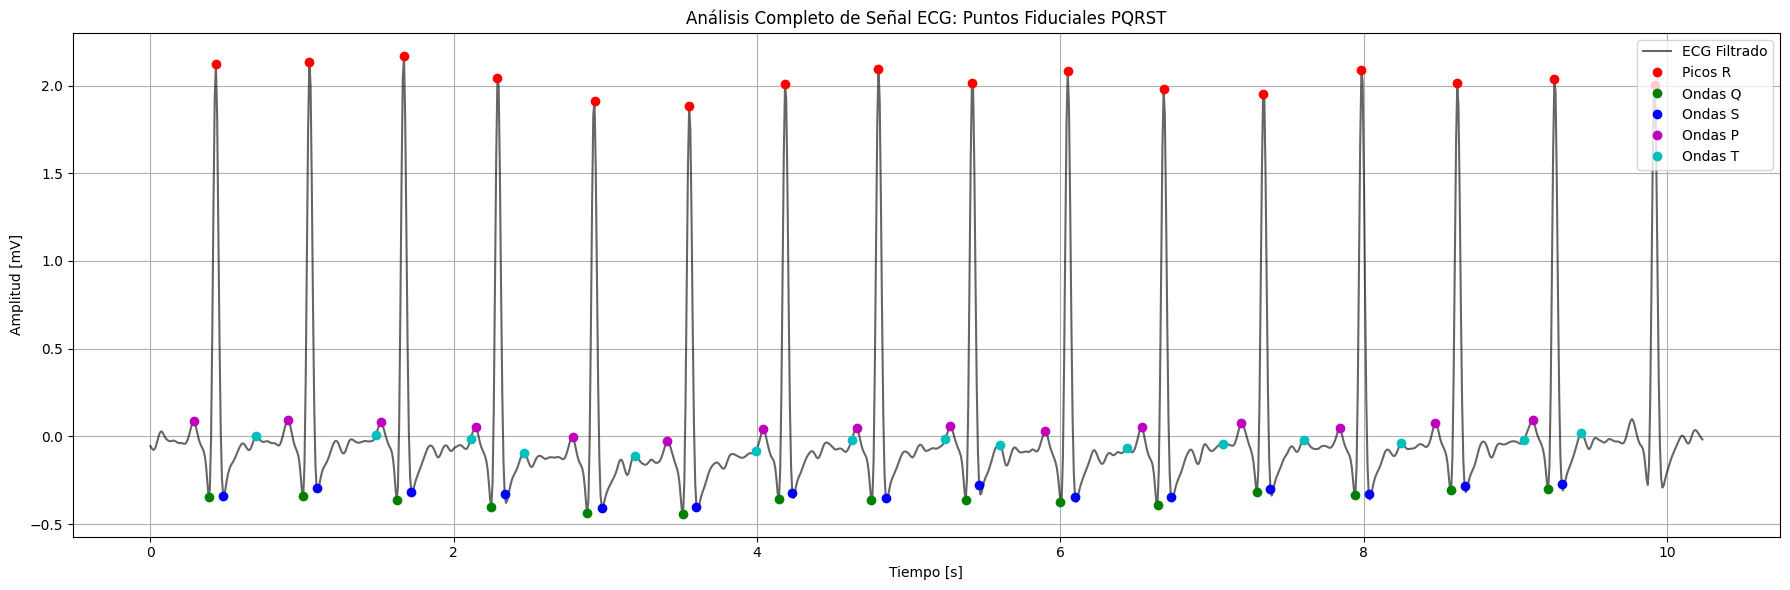

In [5]:
# --- Visualización ---
plt.figure(figsize=(18, 6))

# Graficar la señal filtrada
plt.plot(t, ecg_filtered, 'k-', alpha=0.6, label='ECG Filtrado')

# Superponer puntos fiduciales
plt.plot(t[peaks], ecg_filtered[peaks], 'ro', label='Picos R')
plt.plot(t[q_waves], ecg_filtered[q_waves], 'go', label='Ondas Q')
plt.plot(t[s_waves], ecg_filtered[s_waves], 'bo', label='Ondas S')
plt.plot(t[p_waves], ecg_filtered[p_waves], 'mo', label='Ondas P')
plt.plot(t[t_waves], ecg_filtered[t_waves], 'co', label='Ondas T')

plt.title('Análisis Completo de Señal ECG: Puntos Fiduciales PQRST')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

Tras la extracción de datos y los cálculos algorítmicos, se observaron los siguientes hallazgos clínicos:

* **Frecuencia Cardíaca e Intervalo RR:** Los picos R ocurren regularmente a intervalos de aproximadamente `0.609s`, lo que se traduce en una frecuencia cardíaca media de **98.5 lpm**.
* **Intervalo PR:** Evaluado en aproximadamente `0.118s - 0.125s`. El rango normal del PR es de `0.12s - 0.20s`, ubicándose justo en el límite inferior saludable.
* **Complejo QRS:** El ancho medido es de aproximadamente `0.054s`. Esto es extremadamente rápido y completamente normal (un QRS saludable es típicamente `< 0.12s`).
* **Intervalo QT:** Consistente con las ventanas típicas de repolarización cardíaca.

**Conclusión:**
El identificador `RSIN` sugiere fuertemente un **Ritmo Sinusal** (Ritmo Sinusal Normal). La forma de onda se alinea perfectamente con este diagnóstico: el ritmo es regular, cada complejo QRS está precedido por una onda P adecuada, y todos los anchos de los intervalos se ajustan a los límites fisiológicos.

La frecuencia cardíaca se sitúa justo por debajo del umbral de los 100 lpm (a ~98.5 lpm). El paciente presenta un patrón eléctrico cardíaco completamente normal. Cualquier ligera elevación por encima de los 100 lpm bajo estas condiciones de forma de onda se clasificaría como una **Taquicardia Sinusal** benigna, que típicamente corresponde a un esfuerzo físico natural o estrés fisiológico en lugar de una patología electrofisiológica inherente.